In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys

In [4]:
sys.argv = ['-f'] + ["MIC", "-a", "cpu", "--testunklar"]

In [5]:
import os
sys.path.append("/home/pwiesenbach/BertGCN")
os.chdir("/home/pwiesenbach/BertGCN")

In [6]:
from entry import * 

In [7]:
import importlib
import entry
import logging
importlib.reload(logging)
importlib.reload(entry)

<module 'entry' from '/beegfs/homes/pwiesenbach/BertGCN/entry.py'>

In [8]:
from utils import *
import json 
import pandas as pd
import random
from pathlib import Path
import pickle
from transformers import AutoTokenizer
from torch.utils.data import Subset
import re
from collections import Counter

In [9]:
MODELNAME = Path(PRETRAINEDMODEL).stem
if args.data == "MIC":
    DATASET = "med_indication_all_RF_diag"
    if args.testunklar:
        DATASETPATH =  Path("data") / f"ind.{DATASET}_{args.doclevel}_testunklar"
    else:
        DATASETPATH =  Path("data") / f"ind.{DATASET}_{args.doclevel}"
    BERTSAVEDIR = Path(f"models/finetuned/{args.doclevel}")
elif args.data == "CSC":
    DATASET = "CARDIODE400_main"
    DATASETPATH =  Path("data") / f"ind.{DATASET}"


adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASETPATH)
doc_mask = train_mask + val_mask + test_mask
adj.sum()


nb_node = features.shape[0]
nb_train, nb_val, nb_test = train_mask.sum(), val_mask.sum(), test_mask.sum()
nb_word = nb_node - nb_train - nb_val - nb_test
nb_class = y_train.shape[1]

y = y_train + y_test + y_val
y_train = y_train.argmax(axis=1)
y = y.argmax(axis=1)

tokenizer = AutoTokenizer.from_pretrained(PRETRAINEDMODEL)

if args.data == "MIC":
    if not args.testunklar:
        idx = np.arange(len(dataset))
        random.shuffle(idx)
        train_idx, val_idx, test_idx = (
            idx[: int(len(idx) * 0.7)],
            idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
            idx[int(len(idx) * 0.8) :],
        )
        train_dataset = Subset(dataset, train_idx)
        val_dataset = Subset(dataset, val_idx)
        test_dataset = Subset(dataset, test_idx)
    else:
        _train_idx, test_idx = list(), list()
        for i, x in enumerate(dataset):
            if "unklar" in dataset.LE.classes_[x["labels"]]:
                test_idx.append(i)
            else:
                _train_idx.append(i)
        test_dataset = Subset(dataset, test_idx)
        random.shuffle(_train_idx)
        train_idx, val_idx = (
            _train_idx[: int(len(_train_idx) * 0.9)],
            _train_idx[int(len(_train_idx) * 0.9) :],
        )
        train_dataset = Subset(dataset, train_idx)
        val_dataset = Subset(dataset, val_idx)
        assert len(train_idx) + len(val_idx) == len(_train_idx)

Loading dataset from: data/medindcls_medbert_letter.json


In [313]:
GCNNAME = f"{MODELNAME}_{dataset}.pt"
SAVEDIR = Path(f"models/gcn/{args.mixfactor}/{args.doclevel}")
GCNPATH= SAVEDIR / GCNNAME

IGFILE = SAVEDIR / f"ig_attrs_gcn_{MODELNAME}_{args.data}.npz"
SHAPFILE = SAVEDIR / f"shap_values_gcn_{MODELNAME}_{args.data}.npz"
if args.testunklar:
    IGFILE = SAVEDIR / f"ig_attrs_gcn_{MODELNAME}_{args.data}_testunklar"
    SHAPFILE = SAVEDIR / f"shap_values_gcn_{MODELNAME}_{args.data}_testunklar"
IGFILE

PosixPath('models/gcn/0.5/letter/ig_attrs_gcn_med_bert_local_MIC.npz')

In [314]:
ig_gcn_bert_values = np.load(IGFILE, "rb")['arr_0']
shap_gcn_bert_values = np.load(SHAPFILE, "rb")['arr_0']

In [320]:
ig_gcn_bert_values[0][:10]

array([ 0.00617208, -0.00384835, -0.00349862,  0.00153814, -0.0019635 ,
       -0.00150074, -0.00363294, -0.00057502, -0.00029821, -0.00106191])

In [316]:
ig_gcn_bert_values[0].shape

(2699,)

In [181]:
random.seed(0)
idx = np.arange(len(dataset))
random.shuffle(idx)

train_len = 1889
val_len = 270
test_len = 540
nb_word = 25297

train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)
    
def map_to_idx(x):
    if x < train_len:
        return train_idx[x]
    elif x < val_len + train_len:
        return val_idx[x - train_len]
    else:
        return test_idx[x - val_len - train_len]

In [227]:
top_n_interpret = 3
top_ig_gcn_bert_values = np.argpartition(ig_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_ig_gcn_bert_values = np.vectorize(map_to_idx)(top_ig_gcn_bert_values)
top_shap_gcn_bert_values = np.argpartition(shap_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_shap_gcn_bert_values = np.vectorize(map_to_idx)(top_shap_gcn_bert_values)

In [185]:
first_order_adj = adj @ adj
first_order_adj = first_order_adj.toarray()

In [186]:
top_n_input = 10
top_input_test_rel_nodes = np.argpartition(first_order_adj[test_mask][:, doc_mask], -top_n_input)[:, -top_n_input:]
top_input_test_rel_nodes = np.vectorize(map_to_idx)(top_input_test_rel_nodes)
top_input_test_rel_nodes.max(), top_input_test_rel_nodes.shape

(2688, (540, 10))

In [203]:
s = 0
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

s = 0
for a, b in zip(top_input_test_rel_nodes, top_shap_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

1212
1215


In [204]:
input_only, interpret_only, both = list(), list(), list()
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    input_only.append(np.setdiff1d(a, b))
    interpret_only.append(np.setdiff1d(b, a))
    both.append(np.intersect1d(b, a))
compare_df = pd.DataFrame({"interpret only": interpret_only, "input only": input_only, "both": both}, index=test_idx)
compare_df

,interpret only,input only,both
2298,[],"[2291, 2292, 2295, 2296, 2297, 2298, 2299]","[2293, 2294, 2300]"
2130,[],"[22, 23, 24, 2131, 2134, 2135, 2136]","[2130, 2132, 2133]"
2559,[],"[2556, 2558, 2560, 2561, 2562, 2564, 2565]","[2557, 2559, 2563]"
1046,[1354],"[1044, 1045, 1047, 1048, 1049, 1050, 1051, 1053]","[1046, 1052]"
1991,"[109, 326, 1837]","[75, 76, 79, 80, 82, 83, 84, 1990, 1991, 1992]",[]
...,...,...,...
2094,"[1335, 1337]","[550, 551, 1600, 1601, 1602, 1603, 2092, 2093,...",[2094]
1060,[],"[1056, 1057, 1058, 1060, 1061, 1911, 1912]","[1054, 1055, 1059]"
165,"[86, 87, 88]","[161, 162, 163, 164, 165, 166, 1133, 1136, 113...",[]
1722,[],"[1721, 1722, 1723, 1729, 1730, 1731, 1733]","[1726, 1735, 1736]"


In [205]:
compare_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in compare_df.index]

<AxesSubplot:>

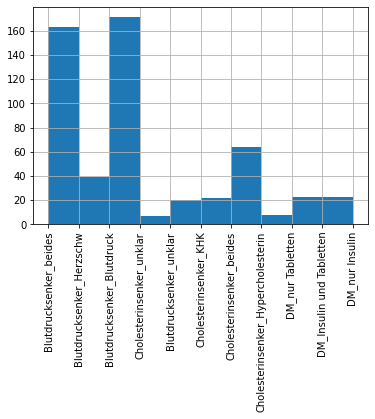

In [206]:
compare_df["data label"].hist(xrot=90)

In [20]:
from model import BertGCN
from ignite.engine import Engine, Events
from ignite.utils import setup_logger
import dgl
import datetime
import torch.utils.data as Data
from ignite.metrics import Accuracy, ClassificationReport, Loss, Precision, Recall
from ignite.handlers.stores import EpochOutputStore
from metrics import SklearnClassificationReport

BATCHSIZE = 8


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = BertGCN(
    nb_class=nb_class,
    pretrained_model=PRETRAINEDMODEL,
    mix_factor=args.mixfactor,
    gcn_layers=2,
    n_hidden=200,
    dropout=0.5,
)

model = model.to(device)
model = model.eval()

# document mask used for update feature
doc_mask = train_mask + val_mask + test_mask

input_ids = torch.cat(
    [
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[train_idx]])),
        torch.zeros((nb_word, tokenizer.model_max_length), dtype=torch.long),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[val_idx]])),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[test_idx]])),
    ]
)

assert np.array_equal(y[:nb_train], dataset.labels[train_idx])
assert np.array_equal(y[nb_train + nb_word : nb_train + nb_word + nb_val], dataset.labels[val_idx])

assert np.array_equal(y[-nb_test:], dataset.labels[test_idx])

adj_norm = normalize_adj(adj + sp.eye(adj.shape[0]))


test_idx_dataset = Data.TensorDataset(torch.arange(nb_node - nb_test, nb_node, dtype=torch.long))

idx_loader_test = Data.DataLoader(test_idx_dataset, batch_size=BATCHSIZE)

graph = dgl.from_scipy(adj_norm.astype("float32"), eweight_name="edge_weight")
graph.ndata["input_ids"] = input_ids
graph.ndata["label"], graph.ndata["train"], graph.ndata["val"], graph.ndata["test"] = (
    torch.LongTensor(y),
    torch.FloatTensor(train_mask),
    torch.FloatTensor(val_mask),
    torch.FloatTensor(test_mask),
)
graph.ndata["label_train"] = torch.LongTensor(y_train)
graph.ndata["cls_feats"] = torch.zeros((nb_node, model.feat_dim))

def update_feature():
    global graph, model
    dataloader = Data.DataLoader(Data.TensorDataset(graph.ndata["input_ids"][doc_mask]), batch_size=64)
    with torch.no_grad():
        model.eval()
        cls_list = []
        logging.info("Udating features...")
        for batch in dataloader:
            input_ids = [x.to(device) for x in batch][0]
            output = model.bert_model(input_ids=input_ids)[0][:, 0]
            cls_list.append(output.cpu())
        cls_feat = torch.cat(cls_list, axis=0)
    graph = graph.to("cpu")
    graph.ndata["cls_feats"][doc_mask] = cls_feat
    
logging.info(f"Loading best gcn model from {GCNPATH} saved on {datetime.datetime.fromtimestamp(GCNPATH.stat().st_ctime)}")
model.load_state_dict(torch.load(GCNPATH, map_location="cpu"))

update_feature()

def eval_step(engine, batch):
    global model, graph
    with torch.no_grad():
        model.eval()
        model = model.to(device)
        graph = graph.to(device)
        (idx,) = [x.to(device) for x in batch]
        y_pred = model(graph, idx)
        y_true = graph.ndata["label"][idx]
        return y_pred, y_true

test_evaluator = Engine(eval_step)
test_evaluator.logger = setup_logger("test evaluator", level=30)

precision = Precision(average=False)
recall = Recall(average=False)
F1 = (precision * recall * 2 / (precision + recall)).mean()
criterion = torch.nn.CrossEntropyLoss()

metrics = {
    "accuracy": Accuracy(),
    "f1": F1,
    "nll": Loss(criterion),
    "cr": SklearnClassificationReport(target_names=dataset.LE.classes_),
    "eos": EpochOutputStore()
}

for n, f in metrics.items():
    f.attach(test_evaluator, n)
    
test_evaluator.run(idx_loader_test)
metrics = test_evaluator.state.metrics

preds = np.vectorize(lambda x: dataset.LE.classes_[x])(np.concatenate([np.argmax(x[0].cpu().numpy(), axis=-1) for x in test_evaluator.state.eos]).ravel()).tolist()

Using backend: pytorch
Some weights of BertModel were not initialized from the model checkpoint at /prj/doctoral_letters/PETGUI/med_bert_local and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [218]:
compare_df["prediction"] = preds
compare_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in compare_df.index]
compare_df["correct pred"] = list(map(int, compare_df["prediction"] == compare_df["data label"]))
compare_df["arznei"] = [re.findall("Arznei (.+?) &", dataset.texts[x])[0] for x in compare_df.index]
compare_df["interpret labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in compare_df["interpret only"]]
compare_df["interpret arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in compare_df["interpret only"]]
compare_df["input labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in compare_df["input only"]]
compare_df["input arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in compare_df["input only"]]
compare_df["label overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(compare_df["interpret labels"], compare_df["input labels"])]
compare_df["arznei overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(compare_df["interpret arznei"], compare_df["input arznei"])]
compare_df["interpret label equals data label"] = [sum([xx==y for xx in x])/3 for x, y in zip(compare_df["interpret labels"], compare_df["data label"])]
compare_df["interpret arznei equals data arznei"] = [sum([xx==y for xx in x])/3 for x, y in zip(compare_df["interpret arznei"], compare_df["arznei"])]
compare_df.describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,540.000000,540.000000,540.000000,540.000000,540.000000
mean,0.933333,0.072840,0.050617,0.072840,0.019753
std,0.249675,0.199057,0.146102,0.185105,0.088627
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,0.666667


In [219]:
compare_df

,interpret only,input only,both,data label,prediction,correct pred,arznei,interpret labels,interpret arznei,input labels,input arznei,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
2298,[],"[2291, 2292, 2295, 2296, 2297, 2298, 2299]","[2293, 2294, 2300]",Blutdrucksenker_beides,Blutdrucksenker_beides,1,Amilorid,[],[],"[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Dilatrend, Carvedilol, Norvasc, Amlodipin, Si...",0.0,0.000000,0.000000,0.000000
2130,[],"[22, 23, 24, 2131, 2134, 2135, 2136]","[2130, 2132, 2133]",Blutdrucksenker_Herzschw,Blutdrucksenker_Herzschw,1,Ramipril,[],[],"[Blutdrucksenker_Herzschw, Blutdrucksenker_Her...","[Dilatrend, Carvedilol, Ramipril, Carvedilol, ...",0.0,0.000000,0.000000,0.000000
2559,[],"[2556, 2558, 2560, 2561, 2562, 2564, 2565]","[2557, 2559, 2563]",Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck,1,Ramipril,[],[],"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Beloc, Delix, Sortis, Atorvastatin, Torem, Me...",0.0,0.000000,0.000000,0.000000
1046,[1354],"[1044, 1045, 1047, 1048, 1049, 1050, 1051, 1053]","[1046, 1052]",Cholesterinsenker_unklar,Cholesterinsenker_KHK,0,Atorvastatin,[Blutdrucksenker_unklar],[Delix],"[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Bisoprolol, Ramipril, HCT, Bisoprolol, Ramipr...",0.0,0.000000,0.000000,0.000000
1991,"[109, 326, 1837]","[75, 76, 79, 80, 82, 83, 84, 1990, 1991, 1992]",[],Blutdrucksenker_unklar,Blutdrucksenker_Blutdruck,0,Metoprololsuccinat,"[DM_nur Tabletten, DM_nur Insulin, Blutdruckse...","[Amaryl, Insulin, Torasemid]","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Torasemid, Torasemid, DelixUNK, Atorvastatin-...",0.0,0.333333,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,"[1335, 1337]","[550, 551, 1600, 1601, 1602, 1603, 2092, 2093,...",[2094],Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck,1,Amlodipin,"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Amlodipin, Ramipril]","[Blutdrucksenker_Herzschw, Blutdrucksenker_Her...","[Candesartan, Torasemid, Belok, Delix, Pravast...",0.0,0.000000,0.666667,0.333333
1060,[],"[1056, 1057, 1058, 1060, 1061, 1911, 1912]","[1054, 1055, 1059]",Blutdrucksenker_beides,Blutdrucksenker_beides,1,Furosemid,[],[],"[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Carvedilol, Aldactone, Spironolacton, Furosem...",0.0,0.000000,0.000000,0.000000
165,"[86, 87, 88]","[161, 162, 163, 164, 165, 166, 1133, 1136, 113...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Sortis,"[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Bisoprolol, Delix, Ramipril]","[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Delix, Ramipril, Norvasc, Amlodipin, Sortis, ...",0.0,0.666667,0.000000,0.000000
1722,[],"[1721, 1722, 1723, 1729, 1730, 1731, 1733]","[1726, 1735, 1736]",Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck,1,Carvedilol,[],[],"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Dilatrend, Carvedilol, Zocor, Esidrix, Hydroc...",0.0,0.000000,0.000000,0.000000


In [208]:
if not os.path.exists("outputs/csvs/"):
    os.mkdir("outputs/csvs/")
compare_df.to_csv("outputs/csvs/compare_df.csv")

<AxesSubplot:>

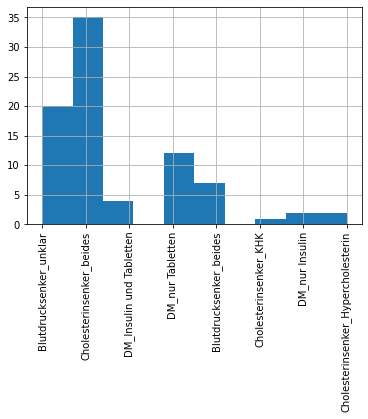

In [230]:
diff_df["data label"].hist(xrot=90)

In [209]:
unklar_df = compare_df[compare_df["data label"].str.contains("unklar")]
unklar_df.describe(include="all")

,interpret only,input only,both,data label,prediction,correct pred,arznei,interpret labels,interpret arznei,input labels,input arznei,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,27,27,27,27,27,27.0,27,27,27,27,27,27.000000,27.000000,27.000000,27.000000
unique,26,27,27,2,3,NaN,15,25,21,27,25,NaN,NaN,NaN,NaN
top,[1354],"[322, 420, 421, 422, 2483, 2484, 2485, 2486, 2...",[],Blutdrucksenker_unklar,Blutdrucksenker_Blutdruck,NaN,Ramipril,[Blutdrucksenker_unklar],"[Beloc, Metoprololsuccinat, Delix]","[Blutdrucksenker_Herzschw, Blutdrucksenker_unk...","[Bisoprolol, Ramipril, HCT, Bisoprolol, Ramipr...",NaN,NaN,NaN,NaN
freq,2,1,1,20,18,NaN,5,3,3,1,2,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.246914,0.259259,0.061728,0.049383
std,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.398636,0.213504,0.185754,0.120671
min,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.333333,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.666667,0.333333,0.000000,0.000000


In [210]:
unklar_df[unklar_df["data label"] == "Cholesterinsenker_unklar"].prediction.unique()

array(['Cholesterinsenker_KHK'], dtype=object)

In [211]:
unklar_df[unklar_df["data label"] == "Blutdrucksenker_unklar"].prediction.unique()

array(['Blutdrucksenker_Blutdruck', 'Blutdrucksenker_Herzschw'],
      dtype=object)

In [212]:
diff_df = compare_df[compare_df['interpret only'].map(len) == 3]
diff_df.head()

,interpret only,input only,both,data label,prediction,correct pred,arznei,interpret labels,interpret arznei,input labels,input arznei,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
1991,"[109, 326, 1837]","[75, 76, 79, 80, 82, 83, 84, 1990, 1991, 1992]",[],Blutdrucksenker_unklar,Blutdrucksenker_Blutdruck,0,Metoprololsuccinat,"[DM_nur Tabletten, DM_nur Insulin, Blutdruckse...","[Amaryl, Insulin, Torasemid]","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Torasemid, Torasemid, DelixUNK, Atorvastatin-...",0.0,0.333333,0.0,0.000000
1865,"[1739, 1740, 1741]","[1862, 1863, 1864, 1865, 1866, 1867, 1868, 186...",[],Blutdrucksenker_unklar,Blutdrucksenker_Blutdruck,0,Ramipril,"[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Beloc, Metoprololsucc, Ramipril]","[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Torem, Beloc, Metoprololsuccinat, Ramipril, A...",0.0,0.666667,0.0,0.333333
1521,"[632, 1893, 1898]","[139, 141, 1519, 1520, 1521, 1522, 1523, 1524,...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Ezetimib,"[DM_nur Insulin, DM_nur Insulin, DM_nur Insulin]","[Insulin, Actrapid, Actrapid]","[Cholesterinsenker_beides, Cholesterinsenker_b...","[Simvastatin, Simvastatin, Ramipril, Inegy, Ez...",0.0,0.000000,0.0,0.000000
1203,"[325, 326, 1291]","[1200, 1201, 1202, 1203, 1204, 1205, 1206, 120...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Atorvastatin,"[DM_nur Insulin, DM_nur Insulin, DM_nur Insulin]","[Actrapid, Insulin, Schnell]","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Bisoprolol, Candesartan, Torasemid, Atorvasta...",0.0,0.000000,0.0,0.000000
454,"[40, 1354, 1355]","[451, 452, 453, 454, 455, 456, 457, 458, 1906,...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Simvastatin,"[Cholesterinsenker_KHK, Blutdrucksenker_unklar...","[Atorvastatin, Delix, Ramipril]","[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Metropolol, Ramipril, Torasemid, Simvastatin,...",0.0,0.333333,0.0,0.000000


In [213]:
diff_df.describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.710843,0.212851,0.212851,0.104418,0.028112
std,0.456127,0.373870,0.241822,0.298722,0.106748
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.333333,0.000000,0.000000
75%,1.000000,0.333333,0.333333,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,0.666667


<AxesSubplot:>

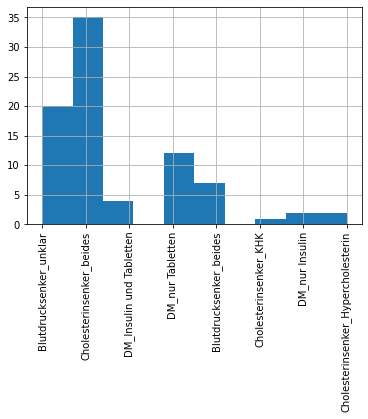

In [214]:
diff_df["data label"].hist(xrot=90)

In [215]:
diff_df[(diff_df["label overlap"]==0) & (diff_df["arznei overlap"]==0)].describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,32.000000,32.0,32.0,32.000000,32.000000
mean,0.812500,0.0,0.0,0.031250,0.020833
std,0.396558,0.0,0.0,0.176777,0.117851
min,0.000000,0.0,0.0,0.000000,0.000000
25%,1.000000,0.0,0.0,0.000000,0.000000
50%,1.000000,0.0,0.0,0.000000,0.000000
75%,1.000000,0.0,0.0,0.000000,0.000000
max,1.000000,0.0,0.0,1.000000,0.666667


In [253]:
sample_df = diff_df.groupby('data label', as_index=True).apply(lambda s: s.sample(min(len(s), 2)))
sample_df.index = sample_df.index.droplevel()

In [301]:
letter_dir = "outputs/letters/diff/"   

if not os.path.exists(letter_dir):
    os.mkdir(letter_dir)

for x in sample_df.index:
    with open(f"{letter_dir}/{x}_{sample_df.loc[x]['data label']}", 'w') as f:
        print(f"Letter {x}: label {sample_df.loc[x]['data label']} | prediction {sample_df.loc[x]['prediction']}", file=f)
        print(" ".join(dataset.texts[x].split()[:512]), file=f)
        print("\nInterpretation letters", file=f)
        prev = None
        for y in sample_df.loc[x]["interpret only"]:
            arznei = re.findall("Arznei (.+?) &", dataset.texts[y])[0]
            print(f"Interpretation letter: {y} | Label: {dataset.LE.classes_[dataset[y]['labels']]} | Medikation: {arznei}", file=f)
            cur = " ".join(dataset.texts[y].split()[:512])
            start = re.search("Arznei .+? &", cur).span()[1]
            if prev is None or prev != cur[start:]:
                print(cur[start:].strip(), file=f)
                
            else:
                print(f"s.o.", file=f)
            prev = cur[start:]
        print("\nInput letters", file=f)
        prev = None
        for y in sample_df.loc[x]["input only"][:3]:
            arznei = re.findall("Arznei (.+?) &", dataset.texts[y])[0]
            print(f"Input letter: {y} | Label: {dataset.LE.classes_[dataset[y]['labels']]} | Medikation: {arznei}", file=f)
            cur = " ".join(dataset.texts[y].split()[:512])
            start = re.search("Arznei .+? &", cur).span()[1]
            if prev is None or prev != cur[start:]:
                print(cur[start:].strip(), file=f)             
            else:
                print(f"s.o.", file=f)
                #print(f"{x}_{sample_df.loc[x]['data label']}")
            prev = cur[start:]